# **Flow**

 1. **Inputting & Importing**
 2. **Data Preprocessing**
    * Missing Values
            a. Cabin
            b. Age
            c. Embarked
            d. Fare
    * Column Transformations
            a. SibSp & Parch
            b. Fare
            c. Age
            d. Ticket
            e. Name
    * Categorical Encoding
            a. Mean Encoding 
            b. One hot Encoding
        
 3. **Correlation & Feature Selection**
 4. **Splitting data**
 5. **Feature Scaling**
 6. **Models & Selection**
 7. **Learning Curve for Hyperparameters**
 8. **Final Model with Hyperparameters**
 9. **Submission**

# **1. Inputting & Importing**

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/titanic/train.csv
/kaggle/input/titanic/test.csv
/kaggle/input/titanic/gender_submission.csv


In [2]:
import seaborn as sns
import matplotlib.pyplot as plt
import random

In [3]:
%config Completer.use_jedi = False
import warnings
warnings.filterwarnings("ignore")
sns.set(rc={'figure.figsize':(18,10)})

# Colors
cyan = '#00FFD1'
red = '#FF007D'
prussian = '#0075FF'
green = '#EEF622'
yellow = '#FFF338'
violet = '#9B65FF'
orange = '#FFA500'
blue = '#00EBFF'
vermillion = '#FF6900'

red2 = '#FF2626'
seagreen = '#28FFBF'
green2 = '#FAFF00'
navyblue = '#04009A'

darkgreen = '#206A5D'
lightgreen = '#CCF6C8'
pink = '#F35588'
mauve = '#BAABDA'
lightblue = '#1CC5DC'
mustard = '#FDB827'
deeppurple = '#723881'



color_list = [cyan,red,prussian,green,violet,orange,yellow,blue,vermillion,red2,seagreen,green2,navyblue,darkgreen,lightgreen,pink,mauve,lightblue,mustard,deeppurple]
plt.rcParams['axes.prop_cycle'] = plt.cycler(color=color_list)

In [4]:
import matplotlib.pyplot as plt
import plotly.express as px
import seaborn as sns
import matplotlib
import re
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from IPython.display import Markdown, display

In [5]:
def printmd(string):
    display(Markdown(string))

In [6]:
train = pd.read_csv('/kaggle/input/titanic/train.csv')
test = pd.read_csv('/kaggle/input/titanic/test.csv')

In [7]:
train.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [8]:
test.head()

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,892,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,NaN,Q
1,893,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,NaN,S
2,894,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,NaN,Q
3,895,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,NaN,S
4,896,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,NaN,S


In [9]:
train.columns

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked'],
      dtype='object')

In [10]:
test.columns

Index(['PassengerId', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp', 'Parch',
       'Ticket', 'Fare', 'Cabin', 'Embarked'],
      dtype='object')

# **2. Data Preprocessing**

## Missing Values

In [11]:
train.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [12]:
test.isnull().sum()

PassengerId      0
Pclass           0
Name             0
Sex              0
Age             86
SibSp            0
Parch            0
Ticket           0
Fare             1
Cabin          327
Embarked         0
dtype: int64

- 20% **Age** values are missing 
- 0.2% **Embarked** values are missing 
- 77% **Cabin** values are missing -> deleting for now
- **Fare** has just 1 missing value

### Cabin

In [13]:
#train_initial = train.copy()
#test_initial = test.copy()

In [14]:
train = train.drop(['Cabin'],axis=1)
test = test.drop(['Cabin'],axis=1)

### Age

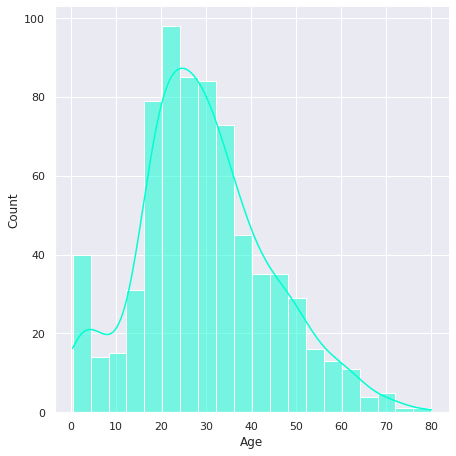

In [15]:
sns.displot(data=train['Age'],kde=True,height=6.5,color=random.choice(color_list));

In [16]:
train['Age'] = train['Age'].fillna(train['Age'].mean())
test['Age'] = test['Age'].fillna(train['Age'].mean())

### Embarked

In [17]:
train['Embarked'].mode()

0    S
dtype: object

In [18]:
train['Embarked'] = train['Embarked'].fillna('S')

### Fare

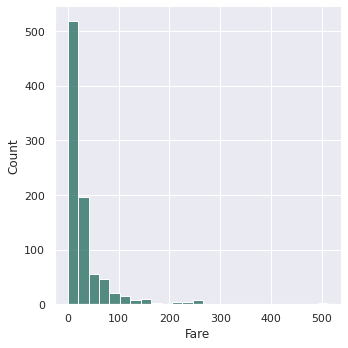

In [19]:
sns.displot(train['Fare'],bins=25,color=random.choice(color_list));

In [20]:
test['Fare'] = test['Fare'].fillna(train['Fare'].mode()[0])

In [21]:
train.isnull().sum()

PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
dtype: int64

In [22]:
test.isnull().sum()

PassengerId    0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
dtype: int64

## Column Transformations

### SibSp and Parch

In [23]:
train['Family'] = train['SibSp']+train['Parch']
test['Family'] = test['SibSp']+test['Parch']
train=train.drop(['SibSp','Parch'],axis=1)
test=test.drop(['SibSp','Parch'],axis=1)

### Fare

In [24]:
train['Fare'] = train['Fare'].astype('int32')
test['Fare'] = test['Fare'].astype('int32')

### Age

In [25]:
train['Age'] = train['Age'].astype('int32')
test['Age'] = test['Age'].astype('int32')

### Ticket

In [26]:
Ticket_temp_train = train['Ticket'].value_counts()
Ticket_temp_test = test['Ticket'].value_counts()

In [27]:
Ticket_temp_train_df = pd.DataFrame({'ticket':Ticket_temp_train.index,'freq':Ticket_temp_train.values})
Ticket_temp_test_df = pd.DataFrame({'ticket':Ticket_temp_test.index,'freq':Ticket_temp_test.values})

In [28]:
def analyse_tickets(freq_to_stop_at,dataframe):
    flag = 'none'
    for i in range(0,len(Ticket_temp_train_df.iloc[:,:])): # iterating a number range
        ticket_name = Ticket_temp_train_df.iloc[i,0]
        ticket_freq = Ticket_temp_train_df.iloc[i,1]

        if(flag != ticket_freq):
            flag=ticket_freq
            printmd('---')
            printmd('### Ticket frequency: **%d**'%(ticket_freq))
            
    
        if (ticket_freq!=freq_to_stop_at-1):
            printmd(' #### *Ticket Name:* **%s**'%(ticket_name))
            display(dataframe.loc[dataframe['Ticket']==ticket_name])
            print('\n\n')# End of one number
        
        else:
            break

In [29]:
analyse_tickets(6,train) # Enter frequency to stop at and dataframe to work with

---

### Ticket frequency: **7**

 #### *Ticket Name:* **CA. 2343**

,PassengerId,Survived,Pclass,Name,Sex,Age,Ticket,Fare,Embarked,Family
159,160,0,3,"Sage, Master. Thomas Henry",male,29,CA. 2343,69,S,10
180,181,0,3,"Sage, Miss. Constance Gladys",female,29,CA. 2343,69,S,10
201,202,0,3,"Sage, Mr. Frederick",male,29,CA. 2343,69,S,10
324,325,0,3,"Sage, Mr. George John Jr",male,29,CA. 2343,69,S,10
792,793,0,3,"Sage, Miss. Stella Anna",female,29,CA. 2343,69,S,10
846,847,0,3,"Sage, Mr. Douglas Bullen",male,29,CA. 2343,69,S,10
863,864,0,3,"Sage, Miss. Dorothy Edith ""Dolly""",female,29,CA. 2343,69,S,10


 #### *Ticket Name:* **347082**

...

,PassengerId,Survived,Pclass,Name,Sex,Age,Ticket,Fare,Embarked,Family
50,51,0,3,"Panula, Master. Juha Niilo",male,7,3101295,39,S,5
164,165,0,3,"Panula, Master. Eino Viljami",male,1,3101295,39,S,5
266,267,0,3,"Panula, Mr. Ernesti Arvid",male,16,3101295,39,S,5
638,639,0,3,"Panula, Mrs. Juha (Maria Emilia Ojala)",female,41,3101295,39,S,5
686,687,0,3,"Panula, Mr. Jaako Arnold",male,14,3101295,39,S,5
824,825,0,3,"Panula, Master. Urho Abraham",male,2,3101295,39,S,5


 #### *Ticket Name:* **CA 2144**

,PassengerId,Survived,Pclass,Name,Sex,Age,Ticket,Fare,Embarked,Family
59,60,0,3,"Goodwin, Master. William Frederick",male,11,CA 2144,46,S,7
71,72,0,3,"Goodwin, Miss. Lillian Amy",female,16,CA 2144,46,S,7
386,387,0,3,"Goodwin, Master. Sidney Leonard",male,1,CA 2144,46,S,7
480,481,0,3,"Goodwin, Master. Harold Victor",male,9,CA 2144,46,S,7
678,679,0,3,"Goodwin, Mrs. Frederick (Augusta Tyler)",female,43,CA 2144,46,S,7
683,684,0,3,"Goodwin, Mr. Charles Edward",male,14,CA 2144,46,S,7


---

### Ticket frequency: **5**

#### **Observations**

* Some people have more than one cabin
* Some people not from the same family are in the same cabin
* should I age categorize?
* There are hardly any cabin names for 3rd class passengers
* 3rd class passengers usually travel in F and G (for the few data that is there)
* passengers on the same ticket are mostly in the same cabin and belong to the same class

**Berth numbers were given for some passengers. Odd for lower berths and even for upper berths.** [source](https://www.encyclopedia-titanica.org/cabins.html)

#### Getting Ticket prefix values

In [30]:
c = -1
tick_1 = {}
for i in range(0,len(train['Ticket'])):
    c=c+1
    match = re.search('^[a-zA-Z]+',train.loc[i,'Ticket'])
    if (match):
        tick_1[c] = match.group()

In [31]:
tick1_s = pd.Series(tick_1)

In [32]:
tick_prefix_train = []
for i in range(0,len(train['Ticket'])):
    match = re.search('^[a-zA-Z]+',train.loc[i,'Ticket'])
    if (match):
        tick_prefix_train.append(match.group())
    else:
        tick_prefix_train.append('Null')
        
        
tick_prefix_test = []
for i in range(0,len(test['Ticket'])):
    match = re.search('^[a-zA-Z]+',test.loc[i,'Ticket'])
    if (match):
        tick_prefix_test.append(match.group())
    else:
        tick_prefix_test.append('Null')

In [33]:
train['Ticket_prefix'] = tick_prefix_train
test['Ticket_prefix'] = tick_prefix_test

In [34]:
train.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,Ticket,Fare,Embarked,Family,Ticket_prefix
0,1,0,3,"Braund, Mr. Owen Harris",male,22,A/5 21171,7,S,1,A
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38,PC 17599,71,C,1,PC
2,3,1,3,"Heikkinen, Miss. Laina",female,26,STON/O2. 3101282,7,S,0,STON
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35,113803,53,S,1,Null
4,5,0,3,"Allen, Mr. William Henry",male,35,373450,8,S,0,Null


-----------

In [35]:
Ticket_pre_df = pd.DataFrame({'prefix':train['Ticket_prefix'].value_counts().index, 'freq':train['Ticket_prefix'].value_counts().values})

In [36]:
def analyse_prefix(freq_to_stop_at,dataframe):
    # booll - enter True if you want null too
    flag = 'none'
    for i in range(1,len(Ticket_pre_df)): # iterating a number range
        ticket_name = Ticket_pre_df.iloc[i,0]
        ticket_freq = Ticket_pre_df.iloc[i,1]

        if(flag != ticket_freq):
            flag=ticket_freq
            printmd('---')
            printmd('### Ticket frequency: **%d**'%(int(ticket_freq)))
            
    
        if (ticket_freq!=freq_to_stop_at-1):
            printmd(' #### *Ticket Name:* **%s**'%(ticket_name))
            display(dataframe.loc[dataframe['Ticket_prefix']==ticket_name])
            print('\n\n')# End of one number
        
        else:
            break

In [37]:
analyse_prefix(11,train) # first arg doesn't work here ##change

---

### Ticket frequency: **60**

 #### *Ticket Name:* **PC**

,PassengerId,Survived,Pclass,Name,Sex,Age,Ticket,Fare,Embarked,Family,Ticket_prefix
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38,PC 17599,71,C,1,PC
30,31,0,1,"Uruchurtu, Don. Manuel E",male,40,PC 17601,27,C,0,PC
31,32,1,1,"Spencer, Mrs. William Augustus (Marie Eugenie)",female,29,PC 17569,146,C,1,PC
34,35,0,1,"Meyer, Mr. Edgar Joseph",male,28,PC 17604,82,C,1,PC
52,53,1,1,"Harper, Mrs. Henry Sleeper (Myna Haxtun)",female,49,PC 17572,76,C,1,PC
64,65,0,1,"Stewart, Mr. Albert A",male,29,PC 17605,27,C,0,PC
96,97,0,1,"Goldschmidt, Mr. George B",male,71,PC 17754,34,C,0,PC
97,98,1,1,"Greenfield, Mr. William Bertram",male,23,PC 17759,63,C,1,PC
118,119,0,1,"Baxter, Mr. Quigg Edmond",male,24,PC 17558,247,C,1,PC
139,140,0,1,"Giglio, Mr. Victor",male,24,PC 17593,79,C,0,PC


---

...

,PassengerId,Survived,Pclass,Name,Sex,Age,Ticket,Fare,Embarked,Family,Ticket_prefix
84,85,1,2,"Ilett, Miss. Bertha",female,17,SO/C 14885,10,S,0,SO


 #### *Ticket Name:* **Fa**

,PassengerId,Survived,Pclass,Name,Sex,Age,Ticket,Fare,Embarked,Family,Ticket_prefix
154,155,0,3,"Olsen, Mr. Ole Martin",male,29,Fa 265302,7,S,0,Fa


 #### *Ticket Name:* **SW**

,PassengerId,Survived,Pclass,Name,Sex,Age,Ticket,Fare,Embarked,Family,Ticket_prefix
226,227,1,2,"Mellors, Mr. William John",male,19,SW/PP 751,10,S,0,SW


Grouping all unique tickets to a common value

In [38]:
for i in range(0,len(Ticket_temp_train_df.iloc[:,:])):
    if (Ticket_temp_train_df.loc[i,'freq'] == 1):
        train['Ticket'] = train['Ticket'].replace([ Ticket_temp_train_df.loc[i,'ticket'] ],'ticketcount_1')
        
for i in range(0,len(Ticket_temp_test_df.iloc[:,:])):
    if (Ticket_temp_test_df.loc[i,'freq'] == 1):
        test['Ticket'] = test['Ticket'].replace([ Ticket_temp_test_df.loc[i,'ticket'] ],'ticketcount_1')

In [39]:
train.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,Ticket,Fare,Embarked,Family,Ticket_prefix
0,1,0,3,"Braund, Mr. Owen Harris",male,22,ticketcount_1,7,S,1,A
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38,ticketcount_1,71,C,1,PC
2,3,1,3,"Heikkinen, Miss. Laina",female,26,ticketcount_1,7,S,0,STON
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35,113803,53,S,1,Null
4,5,0,3,"Allen, Mr. William Henry",male,35,ticketcount_1,8,S,0,Null


In [40]:
train['Ticket'].value_counts()

ticketcount_1    547
347082             7
1601               7
CA. 2343           7
347088             6
                ... 
PC 17569           2
345764             2
29750              2
243847             2
113798             2
Name: Ticket, Length: 135, dtype: int64

### Name

In [41]:
name_titles_train = []
for i in range(0,len(train['Name'])):
    title = (train.loc[i,'Name'].split(', ')[1]).split(' ')[0]
    name_titles_train.append(title)


name_titles_test = []
for i in range(0,len(test['Name'])):
    title = (test.loc[i,'Name'].split(', ')[1]).split(' ')[0]
    name_titles_test.append(title)

In [42]:
train['Title'] = name_titles_train
test['Title'] = name_titles_test

In [43]:
train = train.drop(['Name'],axis=1)
test = test.drop(['Name'],axis=1)

## Categorical Encoding

In [44]:
train.head(7)

,PassengerId,Survived,Pclass,Sex,Age,Ticket,Fare,Embarked,Family,Ticket_prefix,Title
0,1,0,3,male,22,ticketcount_1,7,S,1,A,Mr.
1,2,1,1,female,38,ticketcount_1,71,C,1,PC,Mrs.
2,3,1,3,female,26,ticketcount_1,7,S,0,STON,Miss.
3,4,1,1,female,35,113803,53,S,1,Null,Mrs.
4,5,0,3,male,35,ticketcount_1,8,S,0,Null,Mr.
5,6,0,3,male,29,ticketcount_1,8,Q,0,Null,Mr.
6,7,0,1,male,54,ticketcount_1,51,S,0,Null,Mr.


In [45]:
# Categories

for i in (2,3,5,7,9,10):
    c = train.columns[i]
    printmd('### %s'%(c))
    display(train[c].value_counts())
    print(' ')

### Pclass

3    491
1    216
2    184
Name: Pclass, dtype: int64

### Sex

male      577
female    314
Name: Sex, dtype: int64

### Ticket

...

S    646
C    168
Q     77
Name: Embarked, dtype: int64

### Ticket_prefix

Null     661
PC        60
C         33
A         29
STON      18
SOTON     17
CA        14
S         14
SC        13
W         11
F          6
LINE       4
PP         3
P          2
WE         2
SCO        1
SO         1
Fa         1
SW         1
Name: Ticket_prefix, dtype: int64

### Title

Mr.          517
Miss.        182
Mrs.         125
Master.       40
Dr.            7
Rev.           6
Col.           2
Mlle.          2
Major.         2
Capt.          1
Don.           1
the            1
Jonkheer.      1
Mme.           1
Ms.            1
Sir.           1
Lady.          1
Name: Title, dtype: int64

### Mean Encoding for **Ticket**, **Ticket_prefix** and **Title** columns

In [46]:
def Mean_Encoding(column_name):
    new_smooth_name = column_name+'_smean_encod'
    
    mean = train['Survived'].mean()
    agg= train.groupby(column_name)['Survived'].agg(['count','mean'])
    counts = agg['count']
    means = agg['mean']
    weight = 100
    smooth = (counts*means + weight*mean)/(counts+weight)
    
    train.loc[:,new_smooth_name] = train[column_name].map(smooth)
    test.loc[:,new_smooth_name] = test[column_name].map(smooth)    
    

In [47]:
Mean_Encoding('Ticket')

In [48]:
Mean_Encoding('Ticket_prefix')

In [49]:
Mean_Encoding('Title')

In [50]:
test.isnull().sum()

PassengerId                   0
Pclass                        0
Sex                           0
Age                           0
Ticket                        0
Fare                          0
Embarked                      0
Family                        0
Ticket_prefix                 0
Title                         0
Ticket_smean_encod           59
Ticket_prefix_smean_encod     3
Title_smean_encod             1
dtype: int64

**This means that there are new unique values in the test dataset which weren't mapped to the smooth values we have here**

#### Missing values after mean Encoding

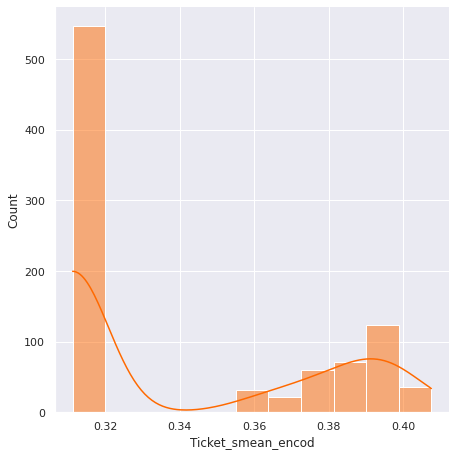

In [51]:
sns.displot(data=train['Ticket_smean_encod'],kde=True,height=6.5,color=random.choice(color_list));

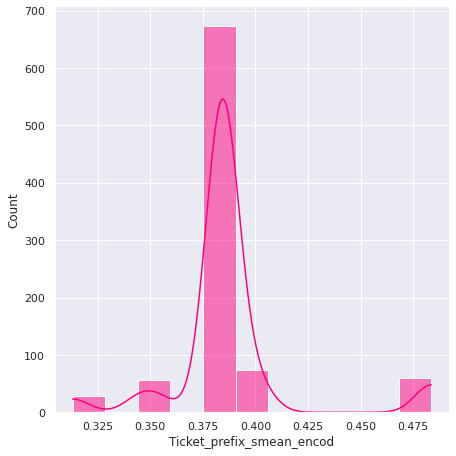

In [52]:
sns.displot(data=train['Ticket_prefix_smean_encod'],kde=True,height=6.5,color=random.choice(color_list));

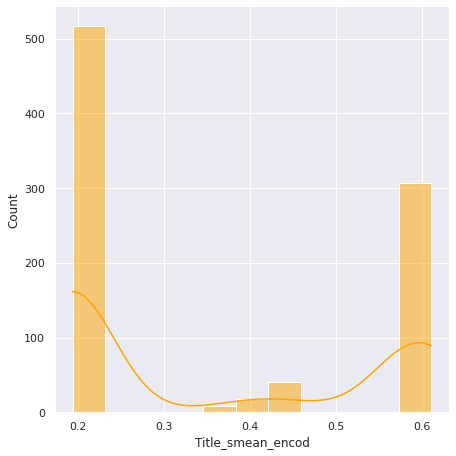

In [53]:
sns.displot(data=train['Title_smean_encod'],kde=True,height=6.5,color=random.choice(color_list));

In [54]:
test['Ticket_smean_encod'] = test['Ticket_smean_encod'].fillna(train['Ticket_smean_encod'].mean())
test['Ticket_prefix_smean_encod'] = test['Ticket_prefix_smean_encod'].fillna(train['Ticket_prefix_smean_encod'].mean())
test['Title_smean_encod'] = test['Title_smean_encod'].fillna(train['Title_smean_encod'].mean())

In [55]:
test.isnull().sum()

PassengerId                  0
Pclass                       0
Sex                          0
Age                          0
Ticket                       0
Fare                         0
Embarked                     0
Family                       0
Ticket_prefix                0
Title                        0
Ticket_smean_encod           0
Ticket_prefix_smean_encod    0
Title_smean_encod            0
dtype: int64

## One Hot Encoding for **Sex**, **Embarked** and **Pclass** columns

In [56]:
# Sex

train['Sex_female'] = pd.get_dummies(train.Sex, prefix='Sex')['Sex_female']
train['Sex_male'] = pd.get_dummies(train.Sex, prefix='Sex')['Sex_male']
test['Sex_female'] = pd.get_dummies(test.Sex, prefix='Sex')['Sex_female']
test['Sex_male'] = pd.get_dummies(test.Sex, prefix='Sex')['Sex_male']

In [57]:
# Pclass

train['Pclass_1'] = pd.get_dummies(train.Pclass, prefix='Pclass')['Pclass_1']
train['Pclass_2'] = pd.get_dummies(train.Pclass, prefix='Pclass')['Pclass_2']
train['Pclass_3'] = pd.get_dummies(train.Pclass, prefix='Pclass')['Pclass_3']

test['Pclass_1'] = pd.get_dummies(test.Pclass, prefix='Pclass')['Pclass_1']
test['Pclass_2'] = pd.get_dummies(test.Pclass, prefix='Pclass')['Pclass_2']
test['Pclass_3'] = pd.get_dummies(test.Pclass, prefix='Pclass')['Pclass_3']

In [58]:
# Embarked

train['Embarked_C'] = pd.get_dummies(train.Embarked, prefix='Embarked')['Embarked_C']
train['Embarked_Q'] = pd.get_dummies(train.Embarked, prefix='Embarked')['Embarked_Q']
train['Embarked_S'] = pd.get_dummies(train.Embarked, prefix='Embarked')['Embarked_S']

test['Embarked_C'] = pd.get_dummies(test.Embarked, prefix='Embarked')['Embarked_C']
test['Embarked_Q'] = pd.get_dummies(test.Embarked, prefix='Embarked')['Embarked_Q']
test['Embarked_S'] = pd.get_dummies(test.Embarked, prefix='Embarked')['Embarked_S']

In [59]:
train.columns

Index(['PassengerId', 'Survived', 'Pclass', 'Sex', 'Age', 'Ticket', 'Fare',
       'Embarked', 'Family', 'Ticket_prefix', 'Title', 'Ticket_smean_encod',
       'Ticket_prefix_smean_encod', 'Title_smean_encod', 'Sex_female',
       'Sex_male', 'Pclass_1', 'Pclass_2', 'Pclass_3', 'Embarked_C',
       'Embarked_Q', 'Embarked_S'],
      dtype='object')

In [60]:
train.head()

,PassengerId,Survived,Pclass,Sex,Age,Ticket,Fare,Embarked,Family,Ticket_prefix,...,Ticket_prefix_smean_encod,Title_smean_encod,Sex_female,Sex_male,Pclass_1,Pclass_2,Pclass_3,Embarked_C,Embarked_Q,Embarked_S
0,1,0,3,male,22,ticketcount_1,7,S,1,A,...,0.313053,0.193491,0,1,0,0,1,0,0,1
1,2,1,1,female,38,ticketcount_1,71,C,1,PC,...,0.483649,0.610595,1,0,1,0,0,1,0,0
2,3,1,3,female,26,ticketcount_1,7,S,0,STON,...,0.393083,0.586468,1,0,0,0,1,0,0,1
3,4,1,1,female,35,113803,53,S,1,Null,...,0.384210,0.610595,1,0,1,0,0,0,0,1
4,5,0,3,male,35,ticketcount_1,8,S,0,Null,...,0.384210,0.193491,0,1,0,0,1,0,0,1


# **3. Correlation and Feature Selection**

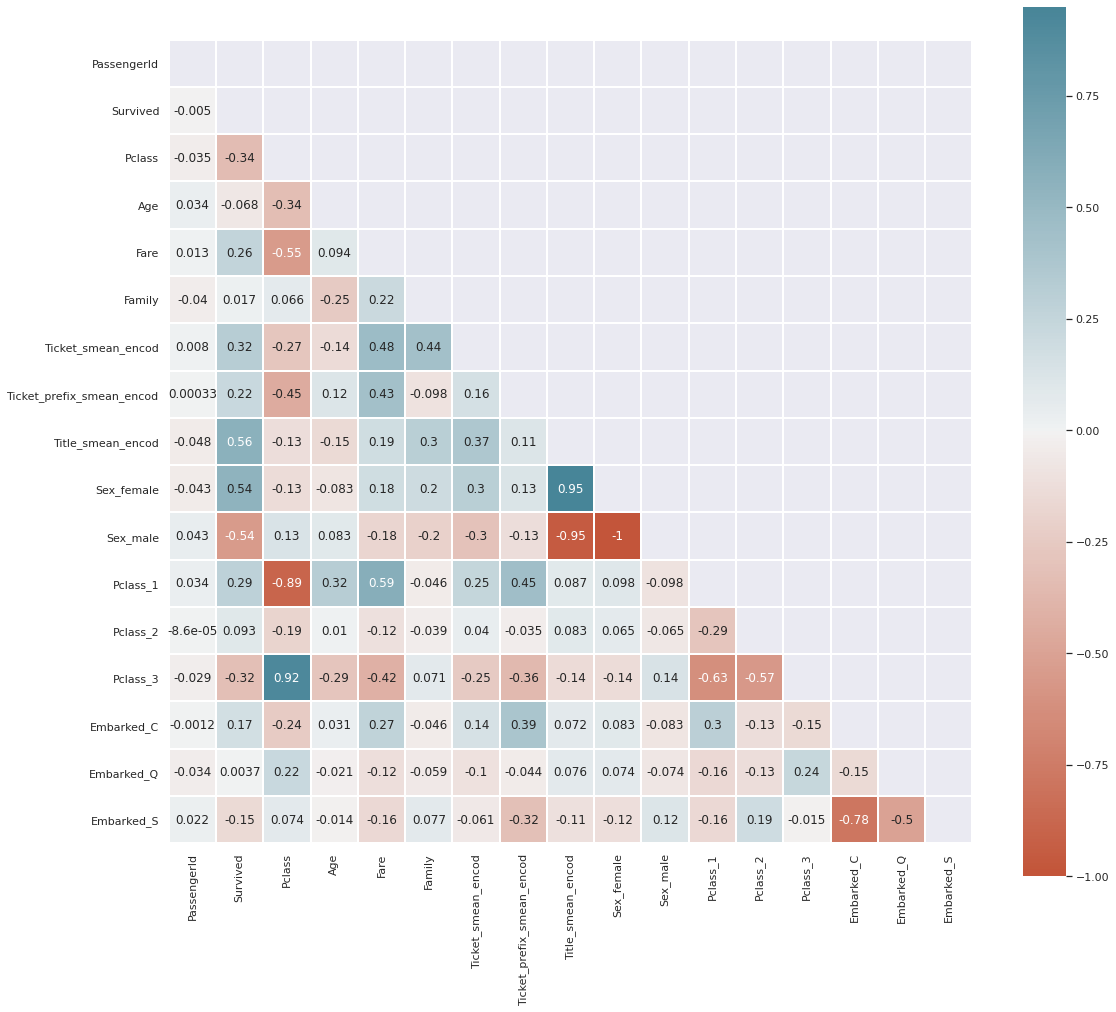

In [61]:
fig, ax = plt.subplots(figsize=(18,16)) 
my_c = sns.diverging_palette(20, 220, as_cmap=True)
mask = np.triu(train.corr())
sns.heatmap(train.corr(),cmap=my_c,linewidths=1.5,ax=ax,annot=True,center=0,square=True,mask=mask);

In [62]:
# df_train = train[['Age','Fare','Family','Ticket_smean_encod','Ticket_prefix_smean_encod','Title_smean_encod','Sex_female','Pclass_1','Pclass_2','Embarked_C',
#        'Embarked_Q','Survived']] # omitted extra dummy variables
# df_test = test[['Age','Fare','Family','Ticket_smean_encod','Ticket_prefix_smean_encod','Title_smean_encod','Sex_female','Pclass_1','Pclass_2','Embarked_C',
#        'Embarked_Q']] # omitted extra dummy variables

# df_train = train[['Age','Fare','Family','Ticket_prefix_smean_encod','Sex_female','Pclass_1','Pclass_2','Embarked_C',
#        'Embarked_Q','Survived']] # omitted extra dummy variables
# df_test = test[['Age','Fare','Family','Ticket_prefix_smean_encod','Sex_female','Pclass_1','Pclass_2','Embarked_C',
#        'Embarked_Q']] # omitted extra dummy variables

# 77.9 accuracy
df_train = train[['Age','Fare','Ticket_prefix_smean_encod','Sex_female','Pclass_1','Pclass_2','Embarked_C',
       'Embarked_Q','Survived']] # omitted extra dummy variables
df_test = test[['Age','Fare','Ticket_prefix_smean_encod','Sex_female','Pclass_1','Pclass_2','Embarked_C',
       'Embarked_Q']] # omitted extra dummy variables



In [63]:
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor

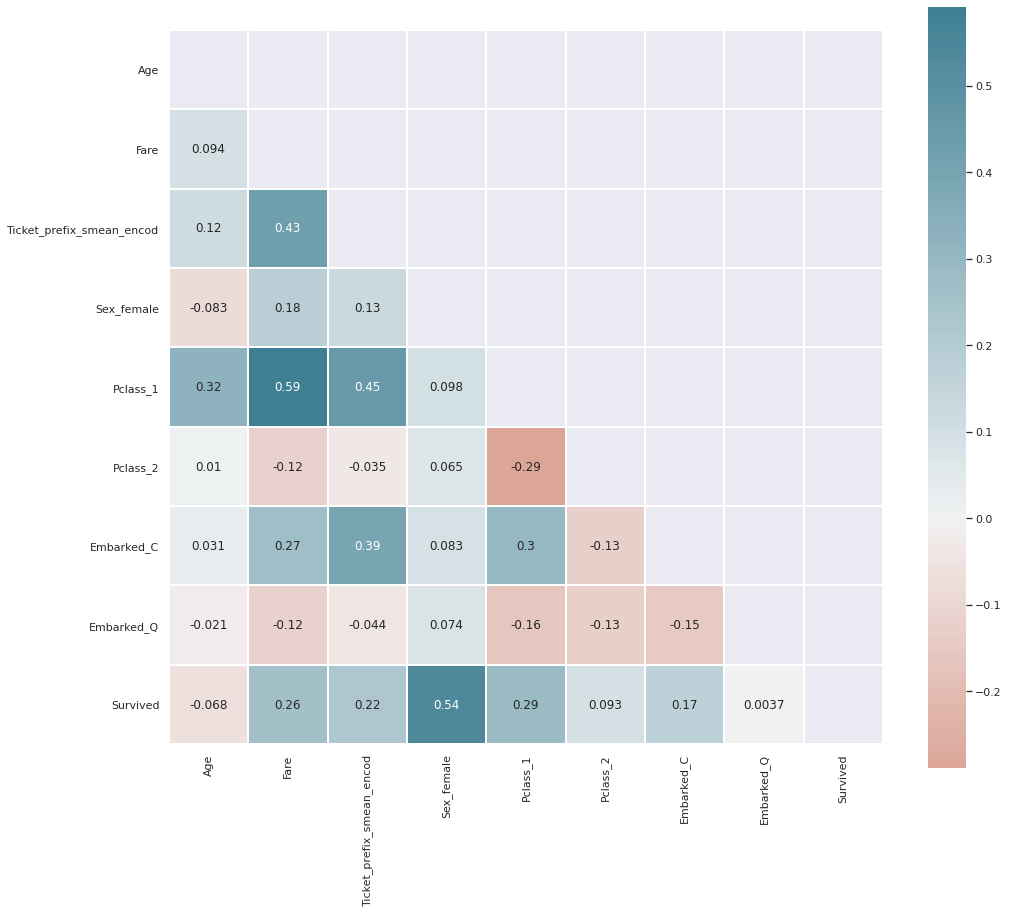

In [64]:
fig, ax = plt.subplots(figsize=(16,14)) 
my_c = sns.diverging_palette(20, 220, as_cmap=True)
mask = np.triu(df_train.corr())
sns.heatmap(df_train.corr(),cmap=my_c,linewidths=1.5,ax=ax,annot=True,center=0,square=True,mask=mask);
plt.savefig('correlation.png')

# **4. Splitting data**

## Train Test Split

In [65]:
from sklearn.model_selection import train_test_split

X = df_train.iloc[:,:-1]
y = df_train.iloc[:,-1]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0)

In [66]:
X.head()

,Age,Fare,Ticket_prefix_smean_encod,Sex_female,Pclass_1,Pclass_2,Embarked_C,Embarked_Q
0,22,7,0.313053,0,0,0,0,0
1,38,71,0.483649,1,1,0,1,0
2,26,7,0.393083,1,0,0,0,0
3,35,53,0.384210,1,1,0,0,0
4,35,8,0.384210,0,0,0,0,0


# **5. Feature Scaling**

In [67]:
from sklearn.preprocessing import StandardScaler
sc = StandardScaler()
X_train.iloc[:,:6] = sc.fit_transform(X_train.iloc[:,:6])
X_test.iloc[:,:6] = sc.transform(X_test.iloc[:,:6])

In [68]:
X_train.head()

,Age,Fare,Ticket_prefix_smean_encod,Sex_female,Pclass_1,Pclass_2,Embarked_C,Embarked_Q
140,-0.044311,-0.328142,-0.091919,1.372075,-0.560047,-0.507888,1,0
439,0.108470,-0.427919,0.470562,-0.728823,-0.560047,1.968937,0,0
817,0.108470,0.110875,-1.073461,-0.728823,-0.560047,1.968937,1,0
378,-0.731826,-0.547651,-0.091919,-0.728823,-0.560047,-0.507888,1,0
491,-0.655435,-0.487785,-1.370984,-0.728823,-0.560047,-0.507888,0,0


In [69]:
sc = StandardScaler()
X.iloc[:,:6] = sc.fit_transform(X.iloc[:,:6])
df_test.iloc[:,:6] = sc.transform(df_test.iloc[:,:6])

# **6. Models & Selection**

**Run only either one of these 4 models, and then the Submission section**

## 1. Random Forest

### Testing accuracy

In [70]:
from sklearn.ensemble import RandomForestClassifier
rfc = RandomForestClassifier(max_depth=13,random_state=0)
rfc.fit(X_train,y_train)

RandomForestClassifier(max_depth=13, random_state=0)

In [71]:
y_pred = rfc.predict(X_test.iloc[:,:])

In [72]:
from sklearn.metrics import accuracy_score
accuracy_score(y_test,y_pred)

0.8659217877094972

### <span style="background-color:LightGreen;">Actual</span> (For Submission)

In [73]:
sc = StandardScaler()
X.iloc[:,:6] = sc.fit_transform(X.iloc[:,:6])
df_test.iloc[:,:6] = sc.transform(df_test.iloc[:,:6])

In [74]:
rfc = RandomForestClassifier()
rfc.fit(X,y)

RandomForestClassifier()

In [75]:
y_pred = rfc.predict(df_test.iloc[:,:])

## 2. Logistic Regression

### Testing accuracy

In [76]:
from sklearn.linear_model import LogisticRegression
lr = LogisticRegression()
lr.fit(X_train,y_train)

LogisticRegression()

In [77]:
y_pred = lr.predict(X_test)

In [78]:
from sklearn.metrics import accuracy_score
accuracy_score(y_test,y_pred)

0.8044692737430168

### <span style="background-color:LightGreen;">Actual</span>

In [79]:
lr = LogisticRegression()
lr.fit(X,y)

y_pred = lr.predict(df_test.iloc[:,:])


## 3. XGBoost

### Testing Accuracy

In [80]:
from sklearn.ensemble import GradientBoostingClassifier

In [81]:
gbc = GradientBoostingClassifier(n_estimators=50, learning_rate=0.06,max_depth=5, random_state=0).fit(X_train, y_train)
#gbc.score(X_test, y_test)

In [82]:
y_pred = gbc.predict(X_test)
accuracy_score(y_test,y_pred)

0.8268156424581006

### <span style="background-color:LightGreen;">Actual</span>

In [83]:
gbc = GradientBoostingClassifier(n_estimators=50, learning_rate=0.06,max_depth=5, random_state=0).fit(X, y)
y_pred = gbc.predict(df_test.iloc[:,:])

## 4. Naive Bayes

### Test

In [84]:
from sklearn.naive_bayes import GaussianNB
gnb = GaussianNB()
gnb.fit(X_train, y_train)

GaussianNB()

In [85]:
y_pred = gnb.predict(X_test)

In [86]:
from sklearn.metrics import accuracy_score
accuracy_score(y_test,y_pred)

0.8044692737430168

### <span style="background-color:LightGreen;">Actual</span>

In [87]:
gnb = GaussianNB()
gnb.fit(X, y)
y_pred = gnb.predict(df_test.iloc[:,:])

# **7. Learning Curve Plot for XGBoost Hyperparameters**

From the following graphs, the point on the x axis where the Test graph peaks just before it begins to decrease afterwards, is where the value is best suited

### Max Depth

In [88]:
values = [i for i in range(1, 15, 1)] ## Max Depth

In [89]:
values

[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14]

In [90]:
train_scores = []
test_scores = []
# evaluate a decision tree for each depth
for i in values:
    # configure the model
    model = GradientBoostingClassifier(n_estimators=50, learning_rate=0.1,max_depth=i, random_state=0)
    # fit model on the training dataset
    model.fit(X_train, y_train)
    # evaluate on the train dataset
    train_yhat = model.predict(X_train)
    train_acc = accuracy_score(y_train, train_yhat)
    train_scores.append(train_acc)
    # evaluate on the test dataset
    test_yhat = model.predict(X_test)
    test_acc = accuracy_score(y_test, test_yhat)
    test_scores.append(test_acc)
    # summarize progress
    print('>%3f, train: %.3f, test: %.3f' % (i, train_acc, test_acc))

>1.000000, train: 0.809, test: 0.793
>2.000000, train: 0.820, test: 0.804
>3.000000, train: 0.861, test: 0.832
>4.000000, train: 0.899, test: 0.849
>5.000000, train: 0.928, test: 0.855
>6.000000, train: 0.947, test: 0.855
>7.000000, train: 0.961, test: 0.844
>8.000000, train: 0.965, test: 0.838
>9.000000, train: 0.968, test: 0.816
>10.000000, train: 0.969, test: 0.810
>11.000000, train: 0.972, test: 0.810
>12.000000, train: 0.972, test: 0.793
>13.000000, train: 0.972, test: 0.799
>14.000000, train: 0.972, test: 0.777


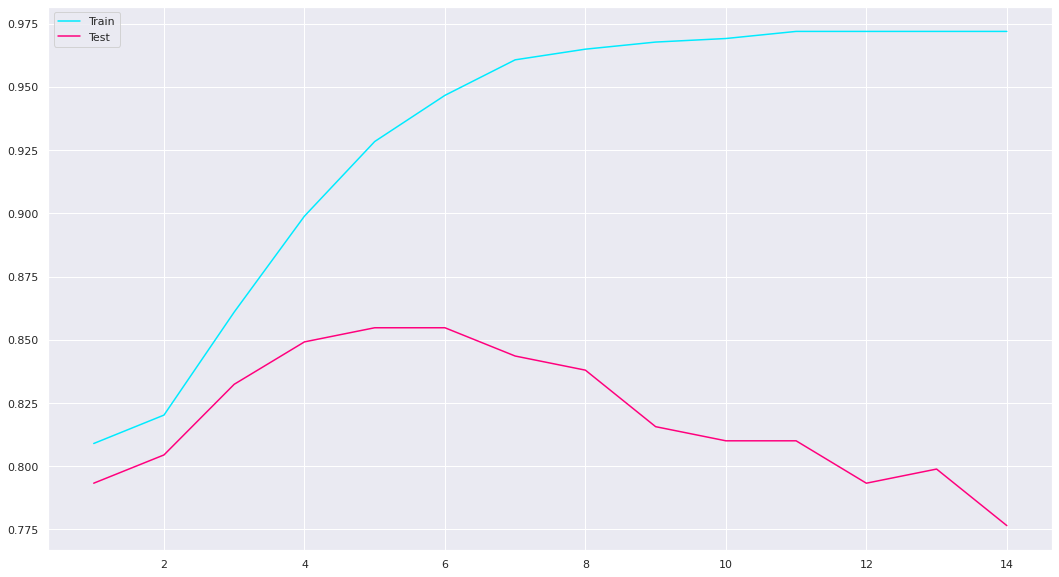

In [91]:
# Max Depth
plt.plot(values,train_scores,color=blue,label='Train');
plt.plot(values,test_scores,color=red,label='Test');
plt.legend();

Therefore, **Max depth = 5**

### N Estimators

In [92]:
values = [i for i in range(75, 200, 5)] ## N Estimators

In [93]:
values

[75,
 80,
 85,
 90,
 95,
 100,
 105,
 110,
 115,
 120,
 125,
 130,
 135,
 140,
 145,
 150,
 155,
 160,
 165,
 170,
 175,
 180,
 185,
 190,
 195]

In [94]:
train_scores = []
test_scores = []
# evaluate a decision tree for each depth
for i in values:
    # configure the model
    model = GradientBoostingClassifier(n_estimators=i, learning_rate=0.1,max_depth=5, random_state=0)
    # fit model on the training dataset
    model.fit(X_train, y_train)
    # evaluate on the train dataset
    train_yhat = model.predict(X_train)
    train_acc = accuracy_score(y_train, train_yhat)
    train_scores.append(train_acc)
    # evaluate on the test dataset
    test_yhat = model.predict(X_test)
    test_acc = accuracy_score(y_test, test_yhat)
    test_scores.append(test_acc)
    # summarize progress
    print('>%3f, train: %.3f, test: %.3f' % (i, train_acc, test_acc))

>75.000000, train: 0.948, test: 0.855
>80.000000, train: 0.951, test: 0.855
>85.000000, train: 0.954, test: 0.860
>90.000000, train: 0.955, test: 0.860
>95.000000, train: 0.955, test: 0.860
>100.000000, train: 0.958, test: 0.860
>105.000000, train: 0.958, test: 0.866
>110.000000, train: 0.958, test: 0.860
>115.000000, train: 0.961, test: 0.860
>120.000000, train: 0.961, test: 0.855
>125.000000, train: 0.962, test: 0.849
>130.000000, train: 0.965, test: 0.849
>135.000000, train: 0.963, test: 0.855
>140.000000, train: 0.963, test: 0.849
>145.000000, train: 0.965, test: 0.844
>150.000000, train: 0.965, test: 0.832
>155.000000, train: 0.966, test: 0.838
>160.000000, train: 0.966, test: 0.838
>165.000000, train: 0.968, test: 0.838
>170.000000, train: 0.968, test: 0.838
>175.000000, train: 0.969, test: 0.838
>180.000000, train: 0.969, test: 0.838
>185.000000, train: 0.969, test: 0.838
>190.000000, train: 0.971, test: 0.838
>195.000000, train: 0.971, test: 0.838


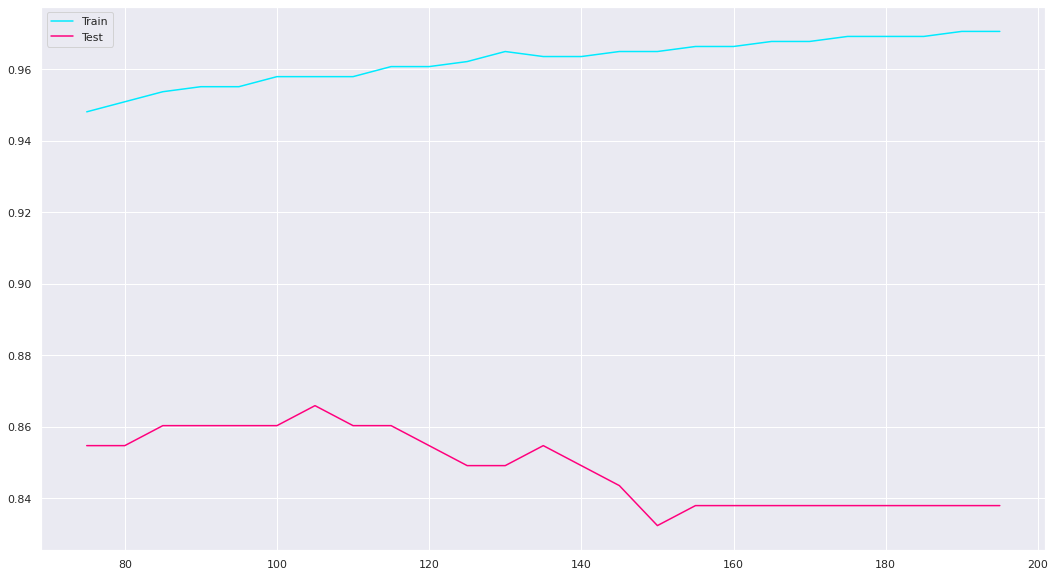

In [95]:
# n_estimators
plt.plot(values,train_scores,color=blue,label='Train');
plt.plot(values,test_scores,color=red,label='Test');
plt.legend();

Therefore,**n_estimators=100**

### Learning Rate

In [96]:
values = [i for i in np.linspace(0.01,0.1,30)] ## Learning Rate

In [97]:
values

[0.01,
 0.01310344827586207,
 0.016206896551724137,
 0.019310344827586208,
 0.02241379310344828,
 0.025517241379310347,
 0.028620689655172414,
 0.031724137931034485,
 0.034827586206896556,
 0.03793103448275863,
 0.04103448275862069,
 0.04413793103448276,
 0.04724137931034483,
 0.050344827586206904,
 0.05344827586206897,
 0.05655172413793104,
 0.05965517241379311,
 0.06275862068965518,
 0.06586206896551725,
 0.06896551724137931,
 0.07206896551724139,
 0.07517241379310345,
 0.07827586206896552,
 0.0813793103448276,
 0.08448275862068966,
 0.08758620689655172,
 0.0906896551724138,
 0.09379310344827586,
 0.09689655172413793,
 0.1]

In [98]:
train_scores = []
test_scores = []
# evaluate a decision tree for each depth
for i in values:
    # configure the model
    model = GradientBoostingClassifier(n_estimators=100, learning_rate=i,max_depth=5, random_state=0)
    # fit model on the training dataset
    model.fit(X_train, y_train)
    # evaluate on the train dataset
    train_yhat = model.predict(X_train)
    train_acc = accuracy_score(y_train, train_yhat)
    train_scores.append(train_acc)
    # evaluate on the test dataset
    test_yhat = model.predict(X_test)
    test_acc = accuracy_score(y_test, test_yhat)
    test_scores.append(test_acc)
    # summarize progress
    print('>%3f, train: %.3f, test: %.3f' % (i, train_acc, test_acc))

>0.010000, train: 0.848, test: 0.827
>0.013103, train: 0.850, test: 0.821
>0.016207, train: 0.857, test: 0.821
>0.019310, train: 0.864, test: 0.810
>0.022414, train: 0.874, test: 0.821
>0.025517, train: 0.878, test: 0.821
>0.028621, train: 0.889, test: 0.816
>0.031724, train: 0.897, test: 0.821
>0.034828, train: 0.896, test: 0.832
>0.037931, train: 0.907, test: 0.838
>0.041034, train: 0.916, test: 0.849
>0.044138, train: 0.921, test: 0.849
>0.047241, train: 0.927, test: 0.855
>0.050345, train: 0.931, test: 0.855
>0.053448, train: 0.931, test: 0.844
>0.056552, train: 0.938, test: 0.849
>0.059655, train: 0.941, test: 0.866
>0.062759, train: 0.938, test: 0.860
>0.065862, train: 0.945, test: 0.860
>0.068966, train: 0.941, test: 0.872
>0.072069, train: 0.944, test: 0.872
>0.075172, train: 0.941, test: 0.866
>0.078276, train: 0.945, test: 0.872
>0.081379, train: 0.948, test: 0.855
>0.084483, train: 0.954, test: 0.866
>0.087586, train: 0.954, test: 0.860
>0.090690, train: 0.956, test: 0.844
>

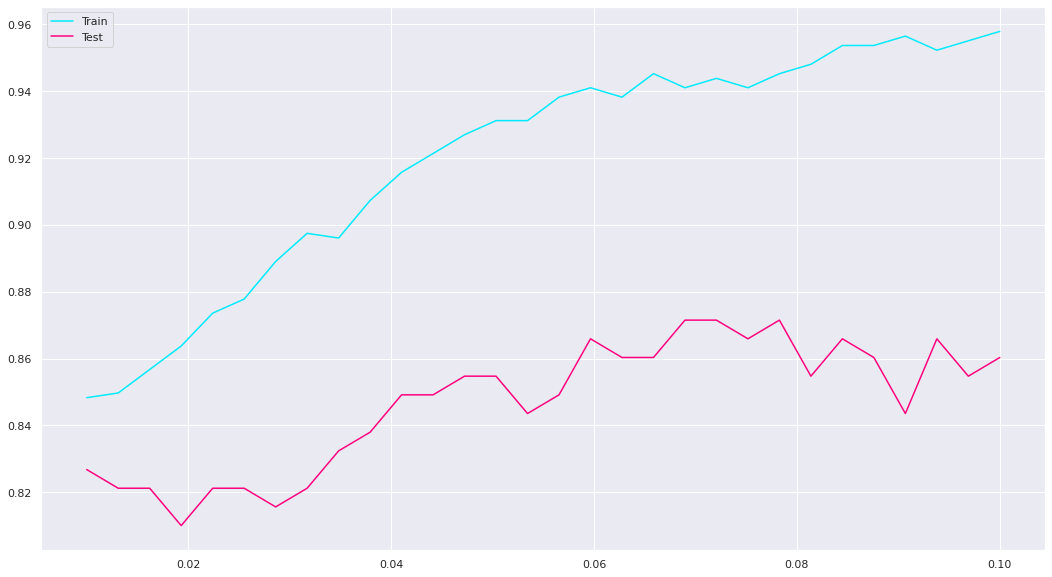

In [99]:
# Learning rate
plt.plot(values,train_scores,color=blue,label='Train');
plt.plot(values,test_scores,color=red,label='Test');
plt.legend();

Therfore, **learning_rate=0.072069**

# **8. Final Model with hyperparameters**

### Test

In [100]:
gbc = GradientBoostingClassifier(n_estimators=100, learning_rate=0.072069,max_depth=5, random_state=0)
gbc.fit(X_train,y_train)
y_pred = gbc.predict(X_test)
accuracy_score(y_test,y_pred)

0.8715083798882681

### <span style="background-color:LightGreen;">**Actual**</span>

In [101]:
gbc = GradientBoostingClassifier(n_estimators=100, learning_rate=0.072069,max_depth=5, random_state=0).fit(X, y)
y_pred = gbc.predict(df_test.iloc[:,:])

# **9. Submission**

In [102]:
Submission = pd.DataFrame({'PassengerID': test.PassengerId, 'Survived': y_pred})

In [103]:
Submission.to_csv('submission.csv', index=False)

# **Conclusion**

XGBoost works the best with 77.9% accuracy.